# Disease Prediction from Medical Data
## CodeAlpha ML Internship — Task 4
### Author: Zeeshan Ahmad


In [1]:
# Install any missing libraries
!pip install scikit-learn pandas numpy matplotlib seaborn --quiet

# Import everything we need
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, confusion_matrix,
                             classification_report, RocCurveDisplay)

print("✅ All libraries imported successfully!")

✅ All libraries imported successfully!


In [2]:
# Load the Heart Disease dataset directly from URL
url = "https://raw.githubusercontent.com/sharmaroshan/Heart-UCI-Dataset/master/heart.csv"
df = pd.read_csv(url)

# Take a first look
print("Shape:", df.shape)  # rows x columns
df.head()                  # show first 5 rows

Shape: (303, 14)


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


In [3]:
# 1. Basic info - data types and null values
print("=== Dataset Info ===")
print(df.info())

# 2. Statistical summary
print("\n=== Statistical Summary ===")
print(df.describe())

# 3. Check for missing values
print("\n=== Missing Values ===")
print(df.isnull().sum())

# 4. How many people have/don't have heart disease?
print("\n=== Target Distribution ===")
print(df['target'].value_counts())

=== Dataset Info ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalach   303 non-null    int64  
 8   exang     303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    int64  
 11  ca        303 non-null    int64  
 12  thal      303 non-null    int64  
 13  target    303 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 33.3 KB
None

=== Statistical Summary ===
              age         sex          cp    trestbps        chol         fbs  \
count  303.000000  303.000000  303.000000  303.000000  303.000000  303.000000   
me

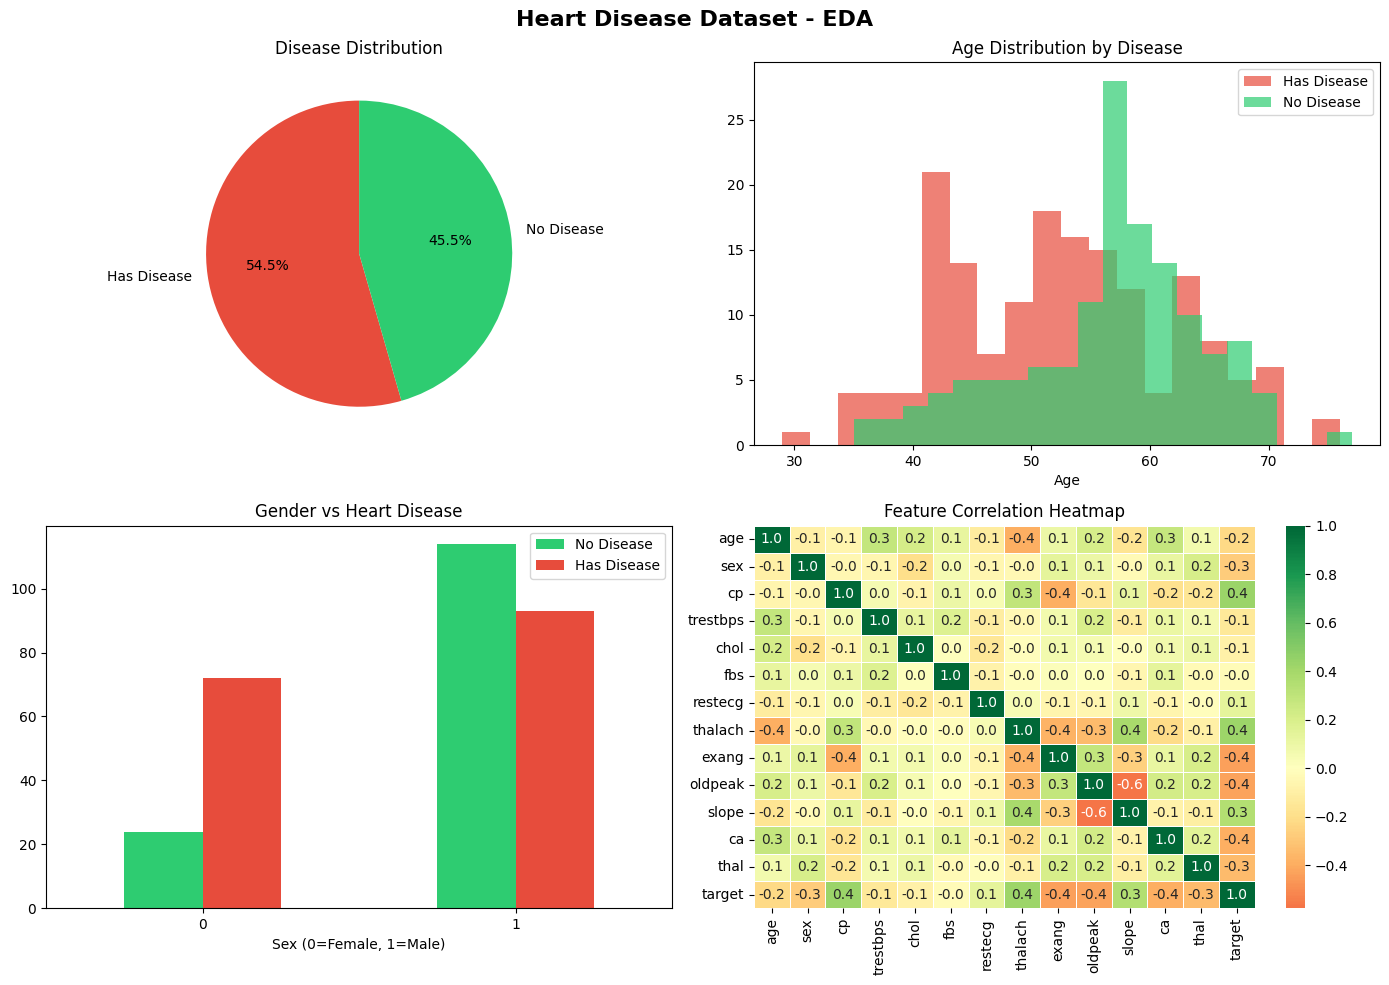

In [4]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Heart Disease Dataset - EDA', fontsize=16, fontweight='bold')

# Chart 1 - Target distribution
axes[0,0].pie([165, 138], labels=['Has Disease', 'No Disease'],
              autopct='%1.1f%%', colors=['#e74c3c','#2ecc71'], startangle=90)
axes[0,0].set_title('Disease Distribution')

# Chart 2 - Age distribution by target
axes[0,1].hist(df[df['target']==1]['age'], alpha=0.7, label='Has Disease',
               color='#e74c3c', bins=20)
axes[0,1].hist(df[df['target']==0]['age'], alpha=0.7, label='No Disease',
               color='#2ecc71', bins=20)
axes[0,1].set_title('Age Distribution by Disease')
axes[0,1].set_xlabel('Age')
axes[0,1].legend()

# Chart 3 - Gender vs Disease
sex_disease = df.groupby(['sex','target']).size().unstack()
sex_disease.plot(kind='bar', ax=axes[1,0], color=['#2ecc71','#e74c3c'],
                 rot=0, legend=True)
axes[1,0].set_title('Gender vs Heart Disease')
axes[1,0].set_xlabel('Sex (0=Female, 1=Male)')
axes[1,0].legend(['No Disease','Has Disease'])

# Chart 4 - Correlation heatmap
corr = df.corr()
sns.heatmap(corr, ax=axes[1,1], annot=True, fmt='.1f',
            cmap='RdYlGn', center=0, linewidths=0.5)
axes[1,1].set_title('Feature Correlation Heatmap')

plt.tight_layout()
plt.show()

In [5]:
# Separate features (X) and target (y)
X = df.drop('target', axis=1)  # everything except target
y = df['target']               # only the target column

print("X shape:", X.shape)  # should be (303, 13)
print("y shape:", y.shape)  # should be (303,)

# Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,      # 20% for testing, 80% for training
    random_state=42     # ensures same split every time you run
)

print("\nTraining samples:", X_train.shape[0])
print("Testing samples: ", X_test.shape[0])

# Scale the features (normalize them)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test  = scaler.transform(X_test)

print("\n✅ Data is ready for training!")

X shape: (303, 13)
y shape: (303,)

Training samples: 242
Testing samples:  61

✅ Data is ready for training!


In [6]:
# === MODEL 1: Logistic Regression ===
lr_model = LogisticRegression(random_state=42, max_iter=1000)
lr_model.fit(X_train, y_train)
lr_pred = lr_model.predict(X_test)

# === MODEL 2: Random Forest ===
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)

# === MODEL 3: Support Vector Machine ===
svm_model = SVC(probability=True, random_state=42)
svm_model.fit(X_train, y_train)
svm_pred = svm_model.predict(X_test)

print("✅ All 3 models trained successfully!")

✅ All 3 models trained successfully!


In [7]:
def evaluate_model(name, y_test, y_pred, model, X_test):
    print(f"\n{'='*45}")
    print(f"  {name}")
    print(f"{'='*45}")
    print(f"  Accuracy  : {accuracy_score(y_test, y_pred):.4f}")
    print(f"  Precision : {precision_score(y_test, y_pred):.4f}")
    print(f"  Recall    : {recall_score(y_test, y_pred):.4f}")
    print(f"  F1-Score  : {f1_score(y_test, y_pred):.4f}")
    print(f"  ROC-AUC   : {roc_auc_score(y_test, model.predict_proba(X_test)[:,1]):.4f}")

evaluate_model("Logistic Regression", y_test, lr_pred, lr_model, X_test)
evaluate_model("Random Forest",       y_test, rf_pred, rf_model, X_test)
evaluate_model("Support Vector Machine", y_test, svm_pred, svm_model, X_test)


  Logistic Regression
  Accuracy  : 0.8525
  Precision : 0.8710
  Recall    : 0.8438
  F1-Score  : 0.8571
  ROC-AUC   : 0.9267

  Random Forest
  Accuracy  : 0.8361
  Precision : 0.8438
  Recall    : 0.8438
  F1-Score  : 0.8438
  ROC-AUC   : 0.9224

  Support Vector Machine
  Accuracy  : 0.8689
  Precision : 0.9000
  Recall    : 0.8438
  F1-Score  : 0.8710
  ROC-AUC   : 0.9310


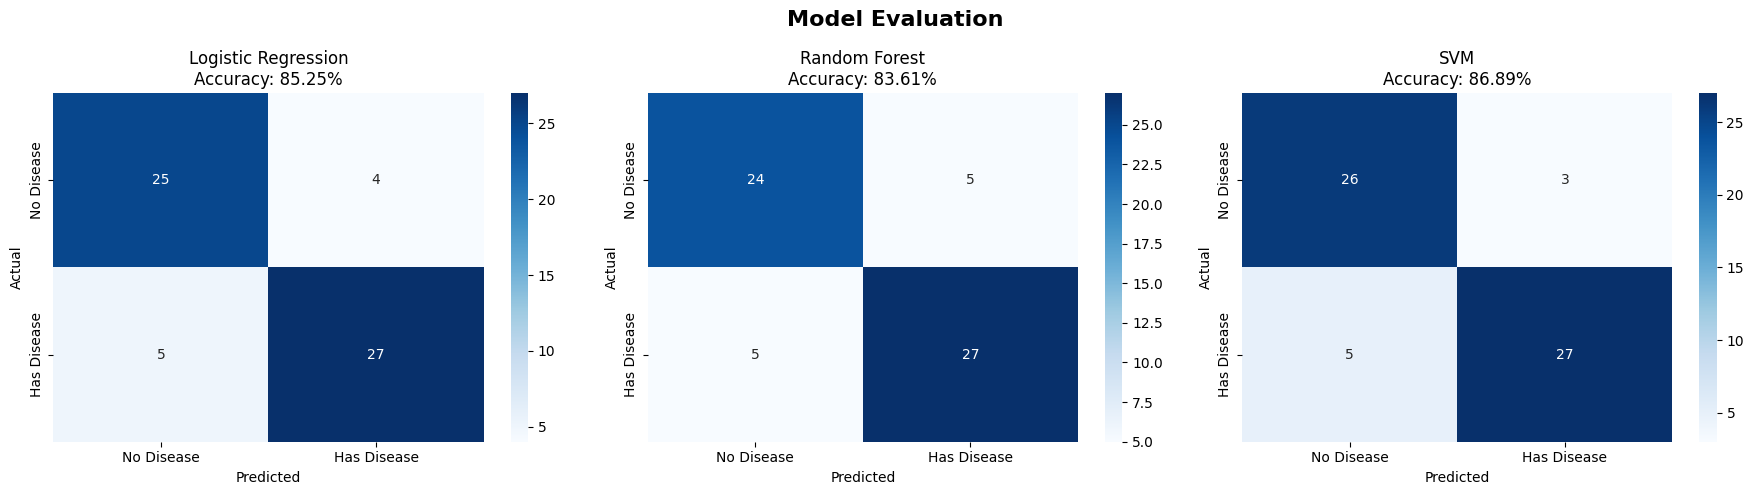

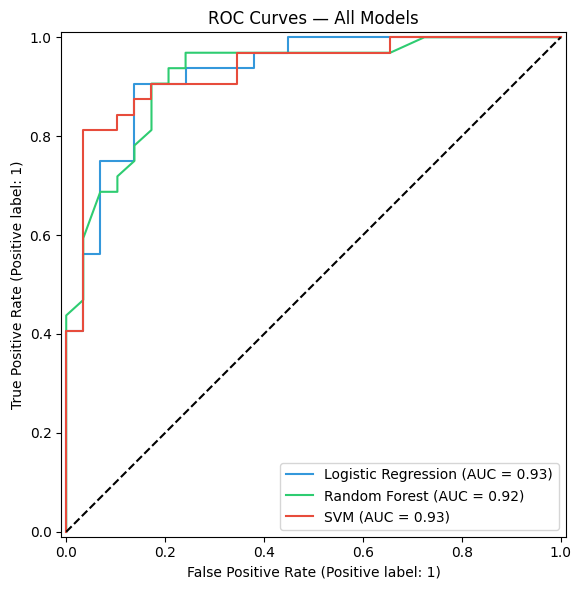

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Model Evaluation', fontsize=16, fontweight='bold')

models      = [lr_model,  rf_model,  svm_model]
predictions = [lr_pred,   rf_pred,   svm_pred]
names       = ['Logistic Regression', 'Random Forest', 'SVM']
colors      = ['#3498db', '#2ecc71', '#e74c3c']

for i, (model, pred, name, color) in enumerate(zip(models, predictions, names, colors)):

    # Confusion Matrix
    cm = confusion_matrix(y_test, pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['No Disease','Has Disease'],
                yticklabels=['No Disease','Has Disease'],
                ax=axes[i])
    axes[i].set_title(f'{name}\nAccuracy: {accuracy_score(y_test, pred):.2%}')
    axes[i].set_ylabel('Actual')
    axes[i].set_xlabel('Predicted')

plt.tight_layout()
plt.show()

# ROC Curves
fig, ax = plt.subplots(figsize=(8, 6))
for model, name, color in zip(models, names, colors):
    RocCurveDisplay.from_estimator(model, X_test, y_test,
                                   name=name, color=color, ax=ax)
ax.set_title('ROC Curves — All Models')
ax.plot([0,1],[0,1],'k--', label='Random Guess')
plt.tight_layout()
plt.show()

In [9]:
import pickle

# Save the best model (SVM) and the scaler
with open('heart_disease_model.pkl', 'wb') as f:
    pickle.dump(svm_model, f)

with open('scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

print("✅ Model saved as heart_disease_model.pkl")
print("✅ Scaler saved as scaler.pkl")

✅ Model saved as heart_disease_model.pkl
✅ Scaler saved as scaler.pkl


In [10]:
import pickle

# Load the saved model and scaler
with open('heart_disease_model.pkl', 'rb') as f:
    loaded_model = pickle.load(f)

with open('scaler.pkl', 'rb') as f:
    loaded_scaler = pickle.load(f)

# New patient data (fake example)
new_patient = pd.DataFrame({
    'age':      [52],
    'sex':      [1],       # 1 = Male
    'cp':       [0],       # 0 = typical angina
    'trestbps': [125],     # blood pressure
    'chol':     [212],     # cholesterol
    'fbs':      [0],       # fasting blood sugar normal
    'restecg':  [1],       # normal ECG
    'thalach':  [168],     # max heart rate
    'exang':    [0],       # no exercise angina
    'oldpeak':  [1.0],     # ST depression
    'slope':    [2],
    'ca':       [2],       # 2 vessels blocked
    'thal':     [3]
})

# Scale the new patient data
new_patient_scaled = loaded_scaler.transform(new_patient)

# Make prediction
prediction = loaded_model.predict(new_patient_scaled)
probability = loaded_model.predict_proba(new_patient_scaled)

print("===== 🏥 Patient Report =====")
print(f"Age       : 52")
print(f"Sex       : Male")
print(f"Result    : {'❤️ Has Heart Disease' if prediction[0]==1 else '✅ No Heart Disease'}")
print(f"Confidence: {max(probability[0])*100:.2f}%")
print("==============================")


===== 🏥 Patient Report =====
Age       : 52
Sex       : Male
Result    : ✅ No Heart Disease
Confidence: 86.85%


## Complete Final Code
All steps combined in one cell — ready for GitHub

✅ Dataset loaded: 303 patients, 14 features

Model                       Accuracy  Precision     Recall         F1    ROC-AUC
---------------------------------------------------------------------------
Logistic Regression           0.8525     0.8710     0.8438     0.8571     0.9267
Random Forest                 0.8361     0.8438     0.8438     0.8438     0.9224
SVM                           0.8689     0.9000     0.8438     0.8710     0.9310


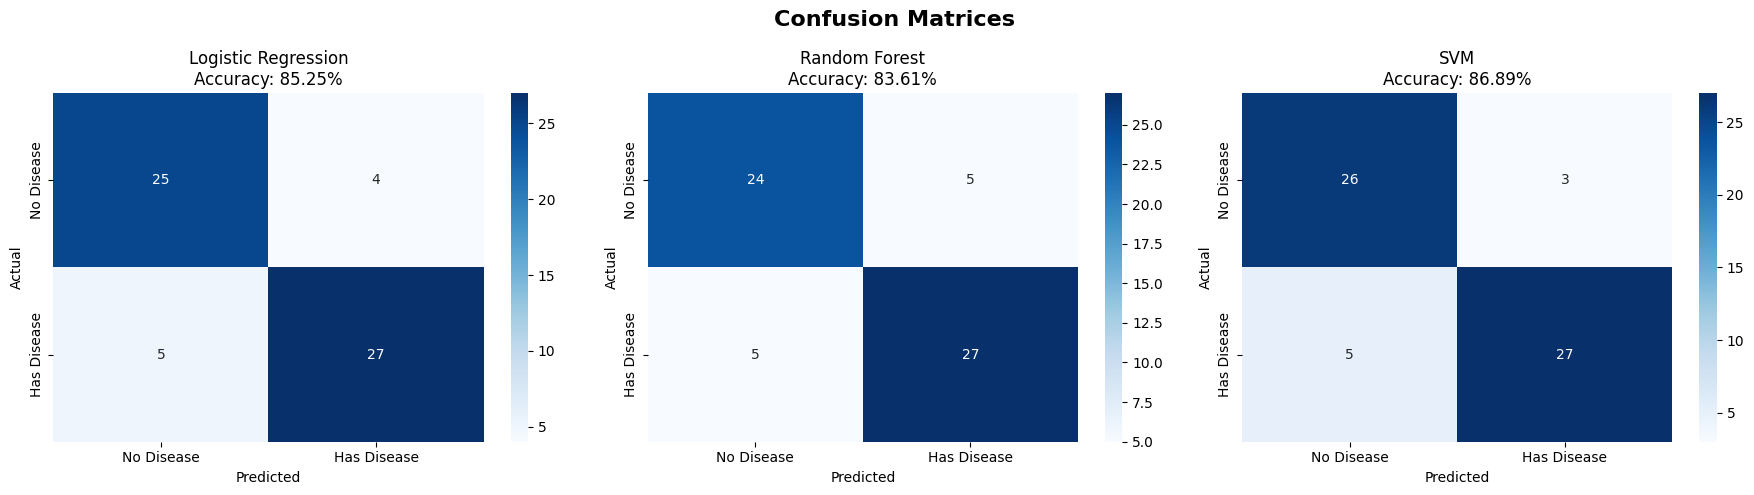

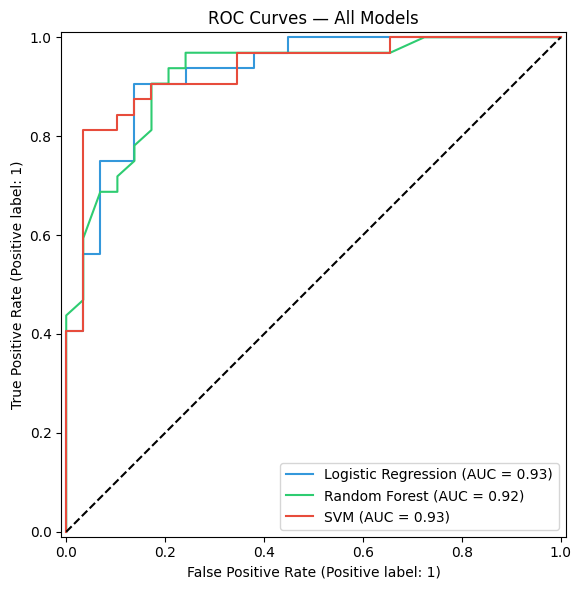


✅ Best model (SVM) saved!

   🏥 Heart Disease Prediction Tool

Enter patient details:
Age: 52
Sex (1=Male, 0=Female): 1
Chest Pain Type (0-3): 2
Resting Blood Pressure: 120
Cholesterol: 110
Fasting Blood Sugar > 120? (1=Yes, 0=No): 1
Resting ECG (0/1/2): 1
Max Heart Rate Achieved: 30
Exercise Induced Angina (1=Yes, 0=No): 1
ST Depression (e.g. 1.0): 1
Slope of ST Segment (0/1/2): 1
Number of Major Vessels (0-4): 2
Thal (0=Normal, 1=Fixed, 2=Reversable, 3=Unknown): 1

===== 🏥 Patient Report =====
Result    : ✅ No Heart Disease
Confidence: 55.27%


In [7]:
# ============================================================
#   DISEASE PREDICTION FROM MEDICAL DATA
#   CodeAlpha Machine Learning Internship — Task 4
#   Author: Zeeshan Ahmad
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, confusion_matrix,
                             RocCurveDisplay)

# ─── 1. LOAD DATA ───────────────────────────────────────────
url = "https://raw.githubusercontent.com/sharmaroshan/Heart-UCI-Dataset/master/heart.csv"
df  = pd.read_csv(url)
print(f"✅ Dataset loaded: {df.shape[0]} patients, {df.shape[1]} features")

# ─── 2. PREPARE DATA ────────────────────────────────────────
X = df.drop('target', axis=1)
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

scaler  = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test  = scaler.transform(X_test)

# ─── 3. TRAIN MODELS ────────────────────────────────────────
models = {
    'Logistic Regression' : LogisticRegression(random_state=42, max_iter=1000),
    'Random Forest'       : RandomForestClassifier(n_estimators=100, random_state=42),
    'SVM'                 : SVC(probability=True, random_state=42)
}

results = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    results[name] = {
        'model'    : model,
        'pred'     : pred,
        'accuracy' : accuracy_score(y_test, pred),
        'precision': precision_score(y_test, pred),
        'recall'   : recall_score(y_test, pred),
        'f1'       : f1_score(y_test, pred),
        'roc_auc'  : roc_auc_score(y_test, model.predict_proba(X_test)[:,1])
    }

# ─── 4. COMPARE MODELS ──────────────────────────────────────
print("\n{:<25} {:>10} {:>10} {:>10} {:>10} {:>10}".format(
    'Model','Accuracy','Precision','Recall','F1','ROC-AUC'))
print("-" * 75)
for name, r in results.items():
    print("{:<25} {:>10.4f} {:>10.4f} {:>10.4f} {:>10.4f} {:>10.4f}".format(
        name, r['accuracy'], r['precision'], r['recall'], r['f1'], r['roc_auc']))

# ─── 5. VISUALIZE ───────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Confusion Matrices', fontsize=16, fontweight='bold')
for i, (name, r) in enumerate(results.items()):
    cm = confusion_matrix(y_test, r['pred'])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['No Disease','Has Disease'],
                yticklabels=['No Disease','Has Disease'],
                ax=axes[i])
    axes[i].set_title(f"{name}\nAccuracy: {r['accuracy']:.2%}")
    axes[i].set_ylabel('Actual')
    axes[i].set_xlabel('Predicted')
plt.tight_layout()
plt.show()

colors = ['#3498db', '#2ecc71', '#e74c3c']
fig, ax = plt.subplots(figsize=(8, 6))
for (name, r), color in zip(results.items(), colors):
    RocCurveDisplay.from_estimator(
        r['model'], X_test, y_test, name=name, color=color, ax=ax)
ax.set_title('ROC Curves — All Models')
ax.plot([0,1],[0,1],'k--', label='Random Guess')
plt.tight_layout()
plt.show()

# ─── 6. SAVE BEST MODEL (SVM) ───────────────────────────────
best_model = results['SVM']['model']
with open('heart_disease_model.pkl', 'wb') as f:
    pickle.dump(best_model, f)
with open('scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)
print("\n✅ Best model (SVM) saved!")

# ─── 7. USER INPUT PREDICTION ───────────────────────────────
print("\n" + "=" * 40)
print("   🏥 Heart Disease Prediction Tool")
print("=" * 40)
print("\nEnter patient details:")

age      = int(input("Age: "))
sex      = int(input("Sex (1=Male, 0=Female): "))
cp       = int(input("Chest Pain Type (0-3): "))
trestbps = int(input("Resting Blood Pressure: "))
chol     = int(input("Cholesterol: "))
fbs      = int(input("Fasting Blood Sugar > 120? (1=Yes, 0=No): "))
restecg  = int(input("Resting ECG (0/1/2): "))
thalach  = int(input("Max Heart Rate Achieved: "))
exang    = int(input("Exercise Induced Angina (1=Yes, 0=No): "))
oldpeak  = float(input("ST Depression (e.g. 1.0): "))
slope    = int(input("Slope of ST Segment (0/1/2): "))
ca       = int(input("Number of Major Vessels (0-4): "))
thal     = int(input("Thal (0=Normal, 1=Fixed, 2=Reversable, 3=Unknown): "))

user_data = pd.DataFrame({
    'age':[age],'sex':[sex],'cp':[cp],'trestbps':[trestbps],
    'chol':[chol],'fbs':[fbs],'restecg':[restecg],'thalach':[thalach],
    'exang':[exang],'oldpeak':[oldpeak],'slope':[slope],
    'ca':[ca],'thal':[thal]
})

scaled_input = scaler.transform(user_data)
prediction   = best_model.predict(scaled_input)
probability  = best_model.predict_proba(scaled_input)

print("\n===== 🏥 Patient Report =====")
print(f"Result    : {'❤️  Has Heart Disease' if prediction[0]==1 else '✅ No Heart Disease'}")
print(f"Confidence: {max(probability[0])*100:.2f}%")
print("==============================")